# Baseline models

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/clean/full_data.csv')

In [3]:
df.head()

,casos,week-canton,relative_risk,urb,tmax_min,tmax_max,tmax_mean,tmax_median,tmin_min,tmin_max,tmin_mean,tmin_median,precip_total,precip_min,precip_max,precip_mean,precip_median
0,2,2020-1-507,0.007854,0,31.206179,34.216175,32.980368,33.278346,31.206179,34.216175,32.980368,33.278346,16.483572,0.0,8.394386,0.686816,0.0
1,0,2020-1-112,0.000000,2,27.300568,31.489710,28.930743,28.016085,27.300568,31.489710,28.930743,28.016085,77.464812,0.0,37.667015,6.455401,0.0
2,29,2020-1-201,0.128283,1,21.756056,29.411386,26.367157,27.010843,21.756056,29.411386,26.367157,27.010843,56.828430,0.0,32.674007,3.551777,0.0
3,4,2020-1-110,0.024902,1,23.514788,24.153862,23.886117,23.937909,23.514788,24.153862,23.886117,23.937909,11.819548,0.0,11.819548,2.954887,0.0
4,0,2020-1-306,0.000000,2,23.673475,24.585056,24.102187,24.075108,23.673475,24.585056,24.102187,24.075108,27.596506,0.0,27.596506,6.899127,0.0


In [4]:
# CHANGE THIS WHEN THE DATA IS OK, THIS IS BASICALLY A SIN TO GET THE MODEL TO WORK
df.drop(columns=['relative_risk'], inplace=True)
df.dropna(inplace=True)

In [5]:
df.shape

(18662, 16)

In [6]:
df = pd.get_dummies(df, columns = ["urb"])

In [7]:
df.head()

,casos,week-canton,tmax_min,tmax_max,tmax_mean,tmax_median,tmin_min,tmin_max,tmin_mean,tmin_median,precip_total,precip_min,precip_max,precip_mean,precip_median,urb_0,urb_1,urb_2
0,2,2020-1-507,31.206179,34.216175,32.980368,33.278346,31.206179,34.216175,32.980368,33.278346,16.483572,0.0,8.394386,0.686816,0.0,True,False,False
1,0,2020-1-112,27.300568,31.489710,28.930743,28.016085,27.300568,31.489710,28.930743,28.016085,77.464812,0.0,37.667015,6.455401,0.0,False,False,True
2,29,2020-1-201,21.756056,29.411386,26.367157,27.010843,21.756056,29.411386,26.367157,27.010843,56.828430,0.0,32.674007,3.551777,0.0,False,True,False
3,4,2020-1-110,23.514788,24.153862,23.886117,23.937909,23.514788,24.153862,23.886117,23.937909,11.819548,0.0,11.819548,2.954887,0.0,False,True,False
4,0,2020-1-306,23.673475,24.585056,24.102187,24.075108,23.673475,24.585056,24.102187,24.075108,27.596506,0.0,27.596506,6.899127,0.0,False,False,True


In [11]:
train = df[df['week-canton'] < '2024-1-101']
val = df[(df['week-canton'] >= '2024-1-101') & (df['week-canton'] < '2025-1-101')]
test = df[df['week-canton'] >= '2025-1-101']

X_train = train.drop(columns = ["casos", "week-canton"])
y_train = train['casos']

X_val = val.drop(columns = ["casos", "week-canton"])
y_val= val['casos']

X_test= test.drop(columns = ["casos", "week-canton"])
y_test = test['casos']

In [12]:
train.shape, val.shape, test.shape

((13020, 18), (3224, 18), (2418, 18))

## Linear regression

In [13]:
reg = LinearRegression().fit(X_train, y_train)

X_test_for_reg = pd.concat([X_val, X_test], axis = 0)
y_test_for_reg = pd.concat([y_val, y_test], axis = 0)

y_pred_reg = reg.predict(X_test_for_reg)

In [14]:
r2_reg = r2_score(y_test_for_reg, y_pred_reg)
mae_reg = mean_absolute_error(y_test_for_reg, y_pred_reg)
mse_reg = mean_squared_error(y_test_for_reg, y_pred_reg)
rmse_reg = mse_reg ** 0.5

In [15]:
print(f"""R2 reg: {round(r2_reg, 3)}
MAE reg: {round(mae_reg, 3)}
MSE reg: {round(mse_reg, 3)}
RMSE reg: {round(rmse_reg, 3)}
      """)

R2 reg: 0.016
MAE reg: 5.507
MSE reg: 174.82
RMSE reg: 13.222
      


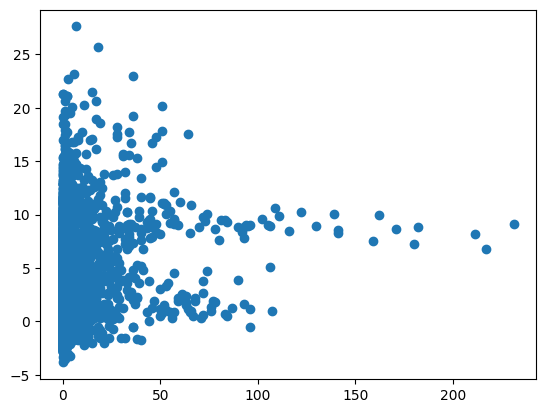

In [16]:
fig, ax = plt.subplots()
ax.scatter(y_test_for_reg, y_pred_reg)